<a href="https://colab.research.google.com/github/pranav-696/ML-Repo./blob/main/multiple_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

%matplotlib inline is what’s known as a Magic Command.

Specifically, it tells the notebook to render your plots and charts directly below the code cell where they are created, and to store them as static images within the notebook document.

In [2]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

Load the data[2]

In [3]:
df = pd.read_csv(url)

# verify successful load with some randomly selected records
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
647,2014,LAND ROVER,RANGE ROVER SPORT V8 5.0 SC FFV,SUV - STANDARD,5.0,8,AS8,Z,16.6,12.3,14.7,19,338
563,2014,JAGUAR,XK CONVERTIBLE,MINICOMPACT,5.0,8,AS6,Z,15.1,10.6,13.1,22,301
582,2014,JEEP,COMPASS 4X4,SUV - SMALL,2.4,4,M5,X,10.3,8.4,9.4,30,216
838,2014,NISSAN,ARMADA 4WD,SUV - STANDARD,5.6,8,A5,X,19.1,13.4,16.5,17,380
795,2014,MINI,COOPER S CONVERTIBLE,MINICOMPACT,1.6,4,M6,Z,9.1,6.7,8.0,35,184


In [4]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [5]:
# Drop categoricals and any unseless columns
df = df.drop(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'TRANSMISSION', 'FUELTYPE',],axis=1)

In [6]:
# Check the correlation of all features with CO2 Emissions
corr_matrix = df.corr()
print(corr_matrix["CO2EMISSIONS"].sort_values(ascending=False))

CO2EMISSIONS                1.000000
FUELCONSUMPTION_CITY        0.898039
FUELCONSUMPTION_COMB        0.892129
ENGINESIZE                  0.874154
FUELCONSUMPTION_HWY         0.861748
CYLINDERS                   0.849685
FUELCONSUMPTION_COMB_MPG   -0.906394
Name: CO2EMISSIONS, dtype: float64


leting predictive features that are not redundant, consider the following scatter matrix, which shows the scatter plots for each pair of input features. The diagonal of the matrix shows each feature's histogram.

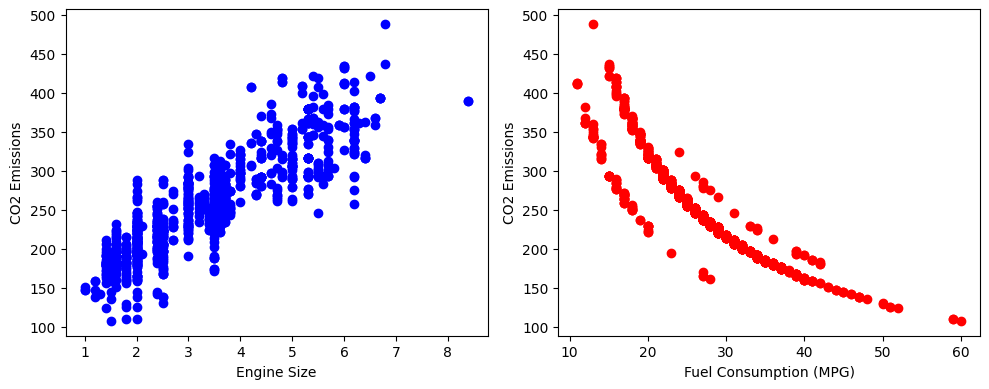

In [8]:
plt.figure(figsize=(10,4))

# Subplot 1: Engine Size
plt.subplot(1, 2, 1)
plt.scatter(df.ENGINESIZE, df.CO2EMISSIONS, color='blue')
plt.xlabel("Engine Size")
plt.ylabel("CO2 Emissions")

# Subplot 2: MPG (Negative Correlation)
plt.subplot(1, 2, 2)
plt.scatter(df.FUELCONSUMPTION_COMB_MPG, df.CO2EMISSIONS, color='red')
plt.xlabel("Fuel Consumption (MPG)")
plt.ylabel("CO2 Emissions")

plt.tight_layout()
plt.show()


Extract the input features and abjust features

In [9]:
X = df.iloc[:,[0,1]].to_numpy()
y = df.iloc[:,[2]].to_numpy()

What it does: You are using iloc (integer-location) to grab the columns by their position.

X gets columns 0 and 1 (ENGINESIZE and FUELCONSUMPTION_COMB_MPG).

y gets column 2 (CO2EMISSIONS).

Why .to_numpy()? While Pandas is great for cleaning, most machine learning libraries (like Scikit-Learn) are optimized to work with NumPy arrays. This converts your table into a raw matrix of numbers.

In [10]:
from sklearn import preprocessing
std_scaler = preprocessing.StandardScaler()
X_std = std_scaler.fit_transform(X)

This is one of the most important steps in preprocessing.

The Problem: Your ENGINESIZE values are small (e.g., 2.0 to 6.0), while your MPG values are larger (e.g., 15 to 40). Machine learning models often get "confused" and give more importance to larger numbers just because they are bigger.

The Solution: StandardScaler re-scales the data. It shifts the data so that the Mean is 0 and the Standard Deviation is 1.

The Math: For every value, it calculates: z=
σ
x−μ
​

In [11]:
pd.DataFrame(X_std).describe().round(2)

,0,1
count,1067.00,1067.00
mean,0.00,-0.00
std,1.00,1.00
min,-1.66,-1.56
25%,-0.95,-1.00
50%,0.04,0.11
75%,0.67,1.23
max,3.57,3.45


It confirms that your scaling worked perfectly. Now, both "Engine Size" and "MPG" are on the exact same scale, meaning the model will treat them with equal mathematical "fairness."

Create train and test datasets

Randomly split your data into train and test sets, using 80% of the dataset for training and reserving the remaining 20% for testing.**bold text**

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_std,y,test_size=0.2,random_state=42)

Build a multiple linear regression model

In [13]:
from sklearn import linear_model

# create a model object
regressor = linear_model.LinearRegression()

# train the model in the training data
regressor.fit(X_train, y_train)

# Print the coefficients
coef_ =  regressor.coef_
intercept_ = regressor.intercept_

print ('Coefficients: ',coef_)
print ('Intercept: ',intercept_)


Coefficients:  [[2.9103674  0.53168927]]
Intercept:  [13.32345061]


In [14]:
# Get the standard scaler's mean and standard deviation parameters
means_ = std_scaler.mean_
std_devs_ = np.sqrt(std_scaler.var_)

# The least squares parameters can be calculated relative to the original, unstandardized feature space as:
coef_original = coef_ / std_devs_
intercept_original = intercept_ - np.sum((means_ * coef_) / std_devs_)

print ('Coefficients: ', coef_original)
print ('Intercept: ', intercept_original)


Coefficients:  [[2.05646044 0.29594114]]
Intercept:  [4.72701565]


Visalisation Tool

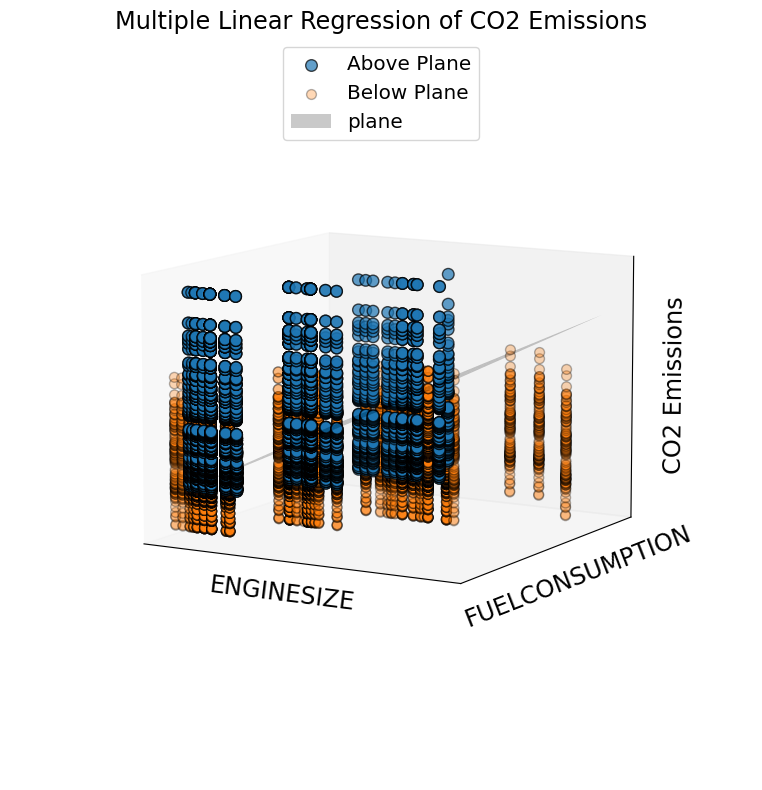

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure X1, X2, and y_test have compatible shapes for 3D plotting
X1 = X_test[:, 0] if X_test.ndim > 1 else X_test
X2 = X_test[:, 1] if X_test.ndim > 1 else np.zeros_like(X1)

# Create a mesh grid for plotting the regression plane
x1_surf, x2_surf = np.meshgrid(np.linspace(X1.min(), X1.max(), 100),
                               np.linspace(X2.min(), X2.max(), 100))

y_surf = intercept_ +  coef_[0,0] * x1_surf  +  coef_[0,1] * x2_surf

# Predict y values using trained regression model to compare with actual y_test for above/below plane colors
y_pred = regressor.predict(X_test.reshape(-1, 1)) if X_test.ndim == 1 else regressor.predict(X_test)
above_plane = y_test >= y_pred
below_plane = y_test < y_pred
above_plane = above_plane[:,0]
below_plane = below_plane[:,0]

# Plotting
fig = plt.figure(figsize=(20, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the data points above and below the plane in different colors
ax.scatter(X1[above_plane], X2[above_plane], y_test[above_plane],  label="Above Plane",s=70,alpha=.7,ec='k')
ax.scatter(X1[below_plane], X2[below_plane], y_test[below_plane],  label="Below Plane",s=50,alpha=.3,ec='k')

# Plot the regression plane
ax.plot_surface(x1_surf, x2_surf, y_surf, color='k', alpha=0.21,label='plane')

# Set view and labels
ax.view_init(elev=10)

ax.legend(fontsize='x-large',loc='upper center')
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
ax.set_box_aspect(None, zoom=0.75)
ax.set_xlabel('ENGINESIZE', fontsize='xx-large')
ax.set_ylabel('FUELCONSUMPTION', fontsize='xx-large')
ax.set_zlabel('CO2 Emissions', fontsize='xx-large')
ax.set_title('Multiple Linear Regression of CO2 Emissions', fontsize='xx-large')
plt.tight_layout()
plt.show()


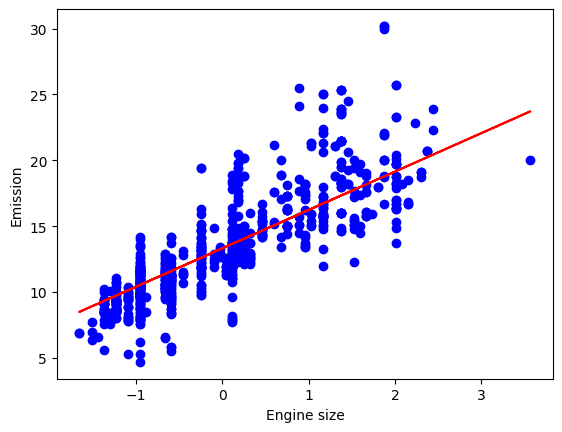

In [16]:
plt.scatter(X_train[:,0], y_train,  color='blue')
plt.plot(X_train[:,0], coef_[0,0] * X_train[:,0] + intercept_[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

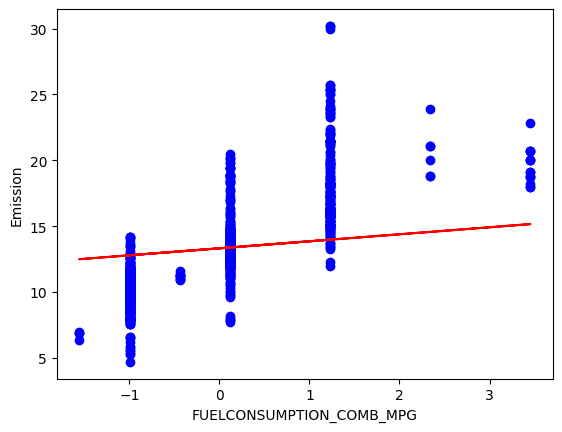

In [17]:
plt.scatter(X_train[:,1], y_train,  color='blue')
plt.plot(X_train[:,1], coef_[0,1] * X_train[:,1] + intercept_[0], '-r')
plt.xlabel("FUELCONSUMPTION_COMB_MPG")
plt.ylabel("Emission")
plt.show()